# XGBOOST (REGRESSION)

In [12]:
import math
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, f1_score, accuracy_score, mean_squared_error

In [14]:
df = pd.read_csv('salary_data.csv')

In [15]:
X = df['YearsExperience']
Y = df['Salary']

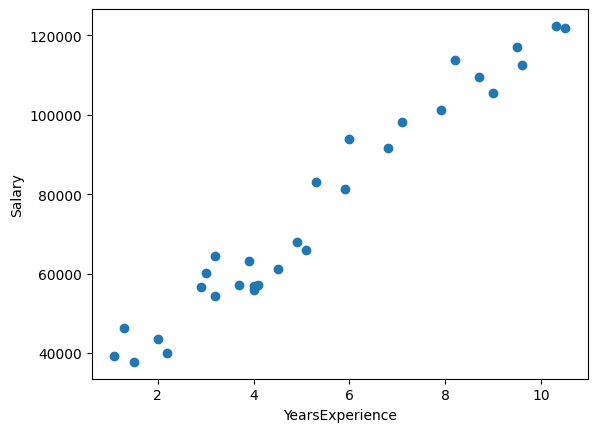

In [16]:
plt.scatter(X, Y)
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [18]:
mdl = xgb.XGBRegressor(
    learning_rate=0.1,
    max_depth=2,
    n_estimators=30,
    subsample=0.8,
    objective= 'reg:squarederror',
)

In [19]:
mdl.fit(X_train, Y_train)
y_pred = mdl.predict(X_test)
mse = mean_squared_error(Y_test, y_pred)
rmse = math.sqrt(mse)
print(rmse)

9186.4548350737


In [20]:
X_sorted = X.sort_values()
y_pred_sorted = mdl.predict(X_sorted)

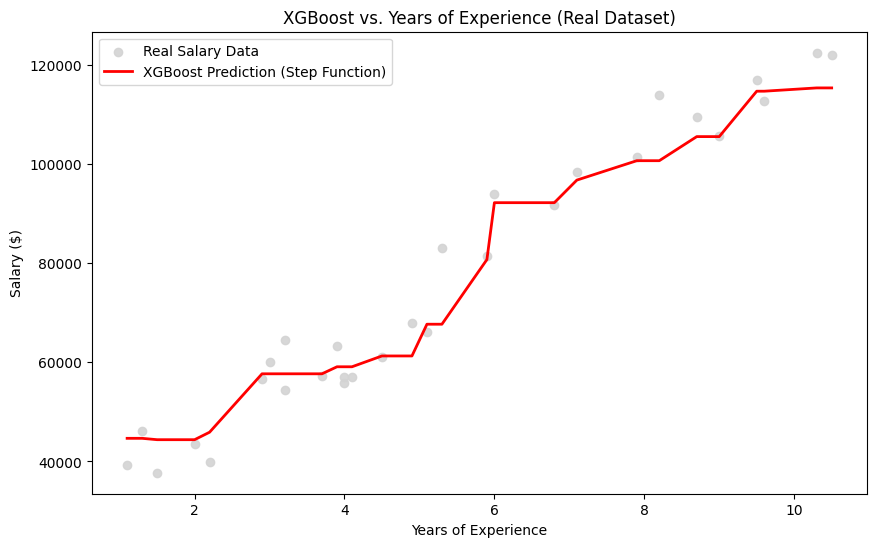

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='lightgray', label='Real Salary Data', alpha=0.9)

plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label='XGBoost Prediction (Step Function)')
plt.title('XGBoost vs. Years of Experience (Real Dataset)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.legend()
plt.show()